# Day 17 of ML 30-Days Challenge

# Task

**K-Nearest Neighbors (K-NN)**: Learn about this simple, instance-based classification algorithm. Understand the importance of choosing the right value for 'k' and how the curse of dimensionality can affect its performance in high-dimensional spaces.

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

###1. Create a 200-row dataset

In [45]:
X, y = make_classification( n_samples=200, n_features=5, n_informative=3, n_redundant=0, n_repeated=0,
                           n_classes=2, n_clusters_per_class=2, class_sep=1.2, flip_y=0.03, random_state=42 )

feature_names = [f"feature_{i}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

df.describe()

,feature_0,feature_1,feature_2,feature_3,feature_4,target
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,-0.449226,0.054817,0.095970,0.602979,-0.098337,0.480000
std,1.364574,0.943538,1.012959,1.461047,1.550307,0.500854
min,-3.577452,-2.696887,-2.423879,-3.209166,-2.823202,0.000000
25%,-1.325966,-0.552967,-0.571485,-0.341592,-1.390503,0.000000
50%,-0.577308,0.005163,0.134362,0.795680,-0.578101,0.000000
75%,0.359614,0.634986,0.744011,1.771488,1.054331,1.000000
max,3.492373,2.573360,2.632382,3.731827,4.798515,1.000000


###2. Train/Test split

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    df[feature_names].values, df["target"].values,
    test_size=0.25, random_state=42, stratify=df["target"].values
)

###3. K-NN on UNSCALED data

In [47]:
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test)
acc_unscaled = accuracy_score(y_test, y_pred_unscaled)


#Your own way of testing accuracy, 😎
count, total_count=0, 0
for i in range(len(y_test)):
    total_count+=1
    if y_test[i]==y_pred_unscaled[i]:
      count+=1

print(f"Accuracy (My way): {(count/total_count)*100}%")
print(f"Accuracy (sklearn): {(acc_unscaled)*100}%")

Accuracy (My way): 94.0%
Accuracy (sklearn): 94.0%


###4. K-NN on SCALED data

In [48]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test, y_pred_scaled)

count, total_count=0, 0
for i in range(len(y_test)):
    total_count+=1
    if y_test[i]==y_pred_scaled[i]:
      count+=1

print(f'Accuracy (My way): {count*100/total_count}%')
print(f'Accuracy (sklearn): {acc_scaled*100}%') #well isn't it same? seems like less dataset

Accuracy (My way): 94.0%
Accuracy (sklearn): 94.0%


###5. Find optimal k (odd numbers 1..31) using elbow on scaled data (no plot)

In [49]:
k_values = list(range(1, 32, 2))
val_scores = []
for k in k_values:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_scaled, y_train)
    preds = m.predict(X_test_scaled)
    val_scores.append(accuracy_score(y_test, preds))

# pick the k with highest accuracy with it choose smallest k
best_idx = int(np.argmax(val_scores))
best_k = k_values[best_idx]
best_acc = val_scores[best_idx]

print(f'\nBest k from elbow search: {best_k}')
print(f'Best validation accuracy: {best_acc:.2f}')


Best k from elbow search: 3
Best validation accuracy: 0.94


###6. Train final model on scaled data with best k

In [50]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred_final = knn_final.predict(X_test_scaled)

final_acc = accuracy_score(y_test, y_pred_final)

print("Unscaled KNN (k=5) accuracy:", round(acc_unscaled, 4))
print("Scaled KNN (k=5) accuracy:", round(acc_scaled, 4))
print("Best k from elbow search:", best_k)
print("Best validation accuracy:", round(best_acc, 4))
print("Final Test Accuracy:", round(final_acc, 4))
print("\nClassification report (final model):\n")
print(classification_report(y_test, y_pred_final, digits=4))

Unscaled KNN (k=5) accuracy: 0.94
Scaled KNN (k=5) accuracy: 0.94
Best k from elbow search: 3
Best validation accuracy: 0.94
Final Test Accuracy: 0.94

Classification report (final model):

              precision    recall  f1-score   support

           0     0.8966    1.0000    0.9455        26
           1     1.0000    0.8750    0.9333        24

    accuracy                         0.9400        50
   macro avg     0.9483    0.9375    0.9394        50
weighted avg     0.9462    0.9400    0.9396        50



###7. Single visualization: Actual vs Predicted (test set)

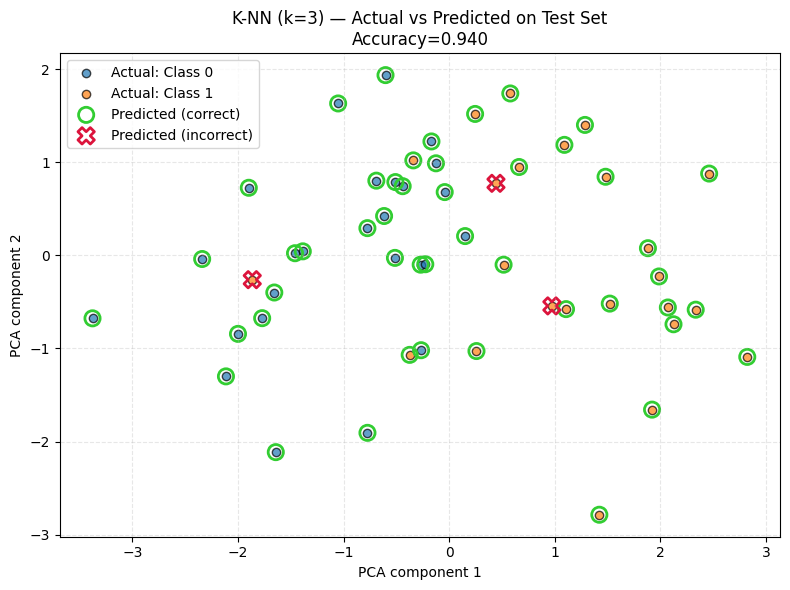

In [51]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_test_2d = pca.fit_transform(X_test_scaled)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_test_2d[y_test==0, 0], X_test_2d[y_test==0, 1],
    c="#1f77b4", marker="o", edgecolor="k", label="Actual: Class 0", alpha=0.7
)
plt.scatter(
    X_test_2d[y_test==1, 0], X_test_2d[y_test==1, 1],
    c="#ff7f0e", marker="o", edgecolor="k", label="Actual: Class 1", alpha=0.7
)

correct = y_test == y_pred_final
incorrect = ~correct

plt.scatter(
    X_test_2d[correct, 0], X_test_2d[correct, 1],
    facecolors='none', edgecolors="limegreen", marker="o", s=120,
    linewidths=2, label="Predicted (correct)"
)
plt.scatter(
    X_test_2d[incorrect, 0], X_test_2d[incorrect, 1],
    facecolors='none', edgecolors="crimson", marker="X", s=140,
    linewidths=2, label="Predicted (incorrect)"
)

plt.title(f"K-NN (k={best_k}) — Actual vs Predicted on Test Set\nAccuracy={final_acc:.3f}")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.legend(loc="best", frameon=True)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()